In [1]:
# load eigen maps with the 2 models, attributions, target reps
import os, sys, glob, pickle
import numpy as np
import pandas as pd
import torch
import logomaker as lm
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
from eigen_steering import EigenMap, MPRAHead, AlphaGenomeMPRA

eigen_steering.WEIGHTS_PATH = os.path.join(REPO, 'pytorch_base_model', 'model_fold_0.safetensors')
CKPT_DIR = os.path.join(REPO, 'models')

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
CTS = ['HepG2', 'K562']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device=DEVICE)
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

with open(os.path.join(REPO, 'virtual_perturbations/libraries/hippo_target_library.pkl'), 'rb') as f:
    target_lib = pickle.load(f)
lib = target_lib['df']
reps = {cond: int(lib[lib['condition'] == cond].iloc[0]['seq_idx'])
        for cond in ['same-same', 'diff-diff', 'same-diff']}
sub_idx = [reps[name] for name in ['same-same', 'diff-diff', 'same-diff']]
groups = list(reps.items())
print('reps:', reps)

def _load_model_patched(self, ct, squeeze=False):
    eigen_steering._load_heavy_deps()
    name = self.model_names[ct]
    ckpt_path = os.path.join(CKPT_DIR, name, 'best_stage2.pt')
    print(f'  Loading {ct}: {ckpt_path}')
    enc = eigen_steering.AlphaGenome.from_pretrained(eigen_steering.WEIGHTS_PATH, device='cpu')
    eigen_steering.remove_all_heads(enc)
    hd = MPRAHead()
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    enc.load_state_dict(ckpt['model_state_dict'], strict=False)
    hd.load_state_dict(ckpt['head_state_dict'])
    return AlphaGenomeMPRA(enc, hd, squeeze=squeeze).to(self.device).eval()

EigenMap._load_model = _load_model_patched
models = em._load_models()
print(f'{len(df)} seqs on {DEVICE}')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
reps: {'same-same': 53997, 'diff-diff': 26012, 'same-diff': 56772}
AlphaGenome patches applied (all functional activations -> nn.Module).
  Loading K562: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/best_stage2.pt
  Loading HepG2: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/best_stage2.pt
56975 seqs on cuda


In [2]:
# Iterative forward screen, rounds 1..N_ROUNDS (paired, per-ct).
# Each run in round r seeds from the cumulative KO of that run's prior winners,
# then finds the next 4bp tile of max marginal necessity.

N_RUNS = 100
N_TRY  = 50
N_REPS = 10
WIN    = 4
N_ROUNDS = 7

eigen_steering._load_heavy_deps()
dinuc_shuf = eigen_steering.dinucleotide_shuffle
ENH_LEN = eigen_steering.ENHANCER_LEN
rng = np.random.default_rng(42)

all_winners = []   # all_winners[r] = winners dict for round r+1

for r in range(N_ROUNDS):
    wnext = {name: {ct: [] for ct in CTS} for name, _ in groups}
    for name, idx in groups:
        wt = em.X[idx:idx+1].float()
        for ct in CTS:
            for run_i in range(N_RUNS):
                prior = [int(W[name][ct][run_i]) for W in all_winners]
                if prior:
                    wt_ko = wt.clone()
                    ko_shuf = dinuc_shuf(wt, n=1,
                                         random_state=int(idx)*333 + run_i*23 + (r+1)*sum(prior))[0]
                    for w in prior:
                        wt_ko[:, :, w:w+WIN] = ko_shuf[:, :, w:w+WIN]
                else:
                    wt_ko = wt
                wt_p = float(em._predict_tensor(wt_ko, models=models, batch_size=4)[ct][0])

                starts = rng.integers(0, ENH_LEN - WIN + 1, size=N_TRY)
                chunks = []
                for s in starts:
                    shuf = dinuc_shuf(wt_ko, n=N_REPS,
                                      random_state=int(idx)*1_000_000 + run_i*1000 + int(s) + r)[0]
                    chim = wt_ko.expand(N_REPS, -1, -1).clone()
                    chim[:, :, s:s+WIN] = shuf[:, :, s:s+WIN]
                    chunks.append(chim)
                all_chim = torch.cat(chunks, dim=0)
                p = em._predict_tensor(all_chim, models=models, batch_size=128)[ct]
                pm = p.reshape(N_TRY, N_REPS).mean(axis=1)
                impact = np.abs(pm - wt_p)
                wnext[name][ct].append(int(starts[int(impact.argmax())]))
            wnext[name][ct] = np.array(wnext[name][ct])
        print(f'r{r+1} {name}: done')
    all_winners.append(wnext)

OUT = os.path.join(REPO, 'genomic_targets', 'data', 'kcee_forward_screen_r1to7.pkl')
with open(OUT, 'wb') as f:
    pickle.dump({'all_winners': all_winners, 'reps': reps,
                 'WIN': WIN, 'N_RUNS': N_RUNS, 'N_TRY': N_TRY, 'N_REPS': N_REPS}, f)
print('saved ->', OUT)

r1 same-same: done
r1 diff-diff: done
r1 same-diff: done
r2 same-same: done
r2 diff-diff: done
r2 same-diff: done
r3 same-same: done
r3 diff-diff: done
r3 same-diff: done
r4 same-same: done
r4 diff-diff: done
r4 same-diff: done
r5 same-same: done
r5 diff-diff: done
r5 same-diff: done
r6 same-same: done
r6 diff-diff: done
r6 same-diff: done
r7 same-same: done
r7 diff-diff: done
r7 same-diff: done
saved -> /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/kcee_forward_screen_r1to7.pkl


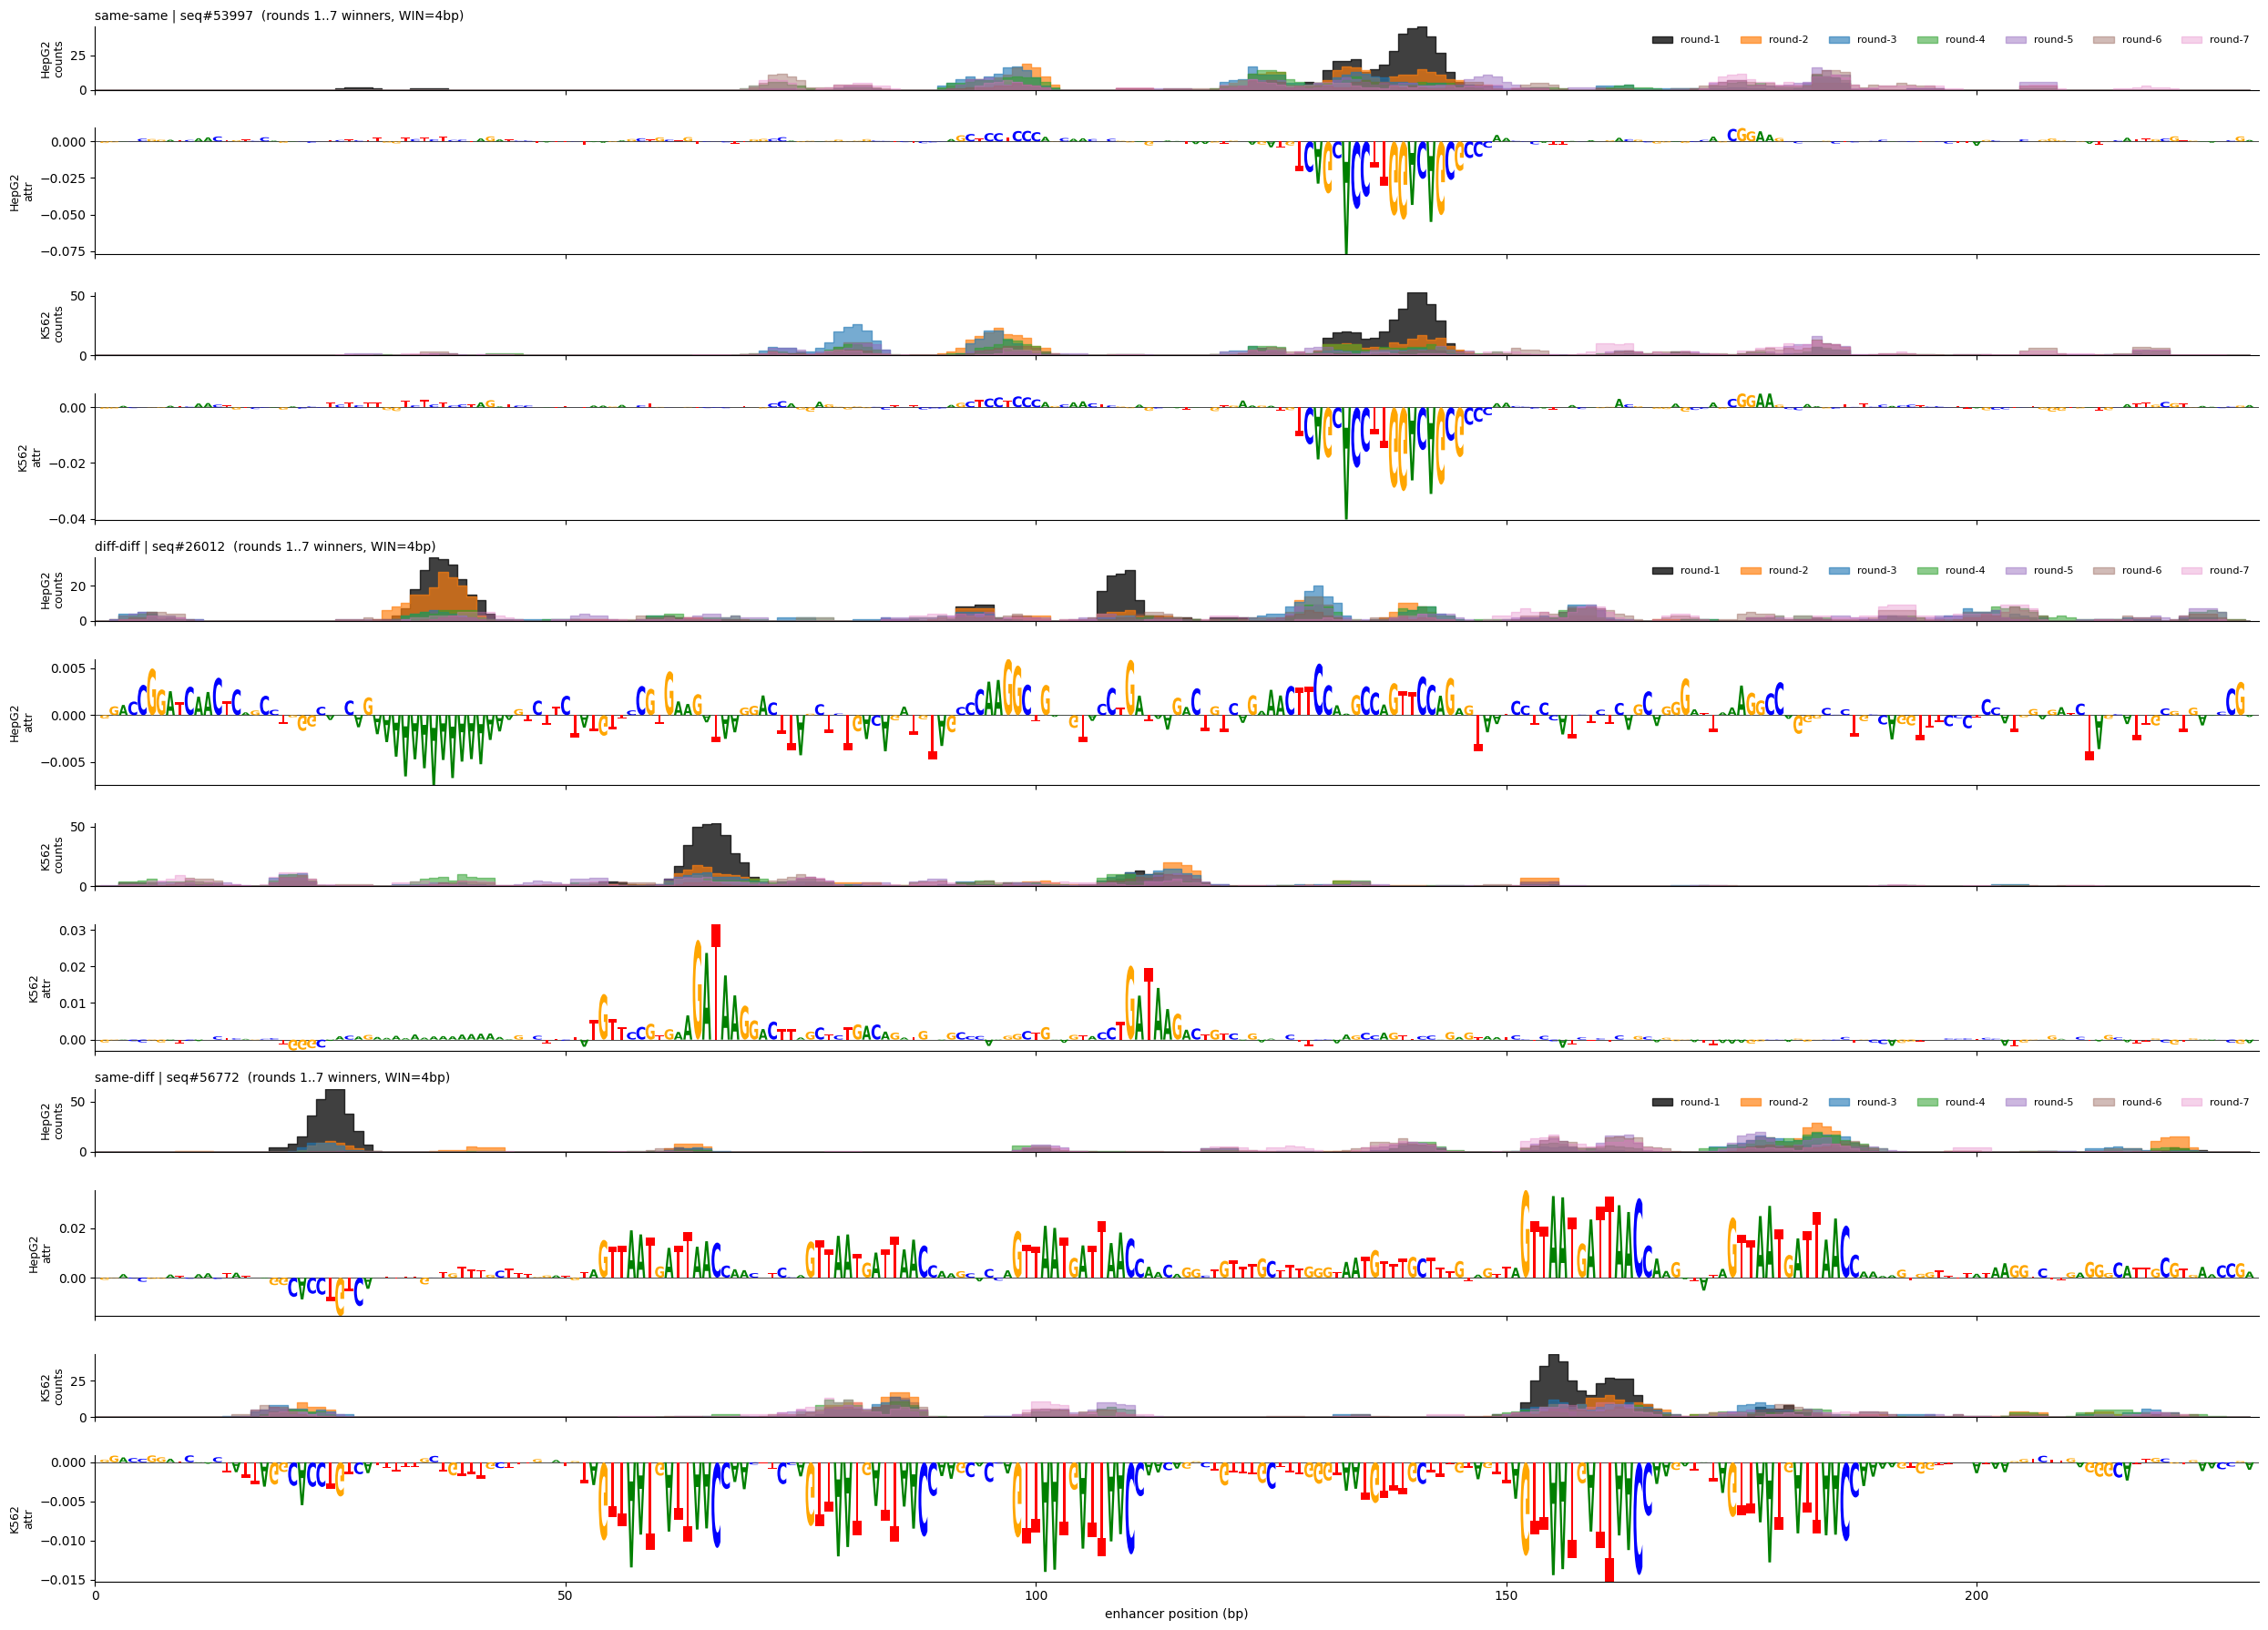

In [3]:
# Logo viz: counts overlay of round-1..N_ROUNDS winners + attribution logo
def coverage_counts(starts_arr, win, length):
    cov = np.zeros(length, dtype=int)
    for s in starts_arr:
        cov[s:s+win] += 1
    return cov

ROUND_COLORS = ['#000000', '#ff7f0e', '#1f77b4', '#2ca02c',
                '#9467bd', '#8c564b', '#e377c2']
n_seqs   = len(groups)
ROWS_PER = 4
xs = np.arange(ENH_LEN)

fig, axes = plt.subplots(ROWS_PER * n_seqs, 1,
                         figsize=(25, 3 * ROWS_PER * n_seqs / 2),
                         sharex=True,
                         gridspec_kw={'height_ratios': [1, 2, 1, 2] * n_seqs})

for gi, (name, idx) in enumerate(groups):
    base = gi * ROWS_PER
    for ci, ct in enumerate(CTS):
        ax_d = axes[base + 2*ci]
        ax_l = axes[base + 2*ci + 1]

        ymax = 1
        for r, W in enumerate(all_winners):
            d = coverage_counts(W[name][ct], WIN, ENH_LEN)
            alpha = max(0.75 - r*0.07, 0.3)
            ax_d.fill_between(xs, d, 0, color=ROUND_COLORS[r], alpha=alpha,
                              step='mid', label=f'round-{r+1}')
            ymax = max(ymax, int(d.max()))
        ax_d.set_ylim(0, ymax)
        ax_d.set_ylabel(f'{ct}\ncounts', fontsize=9)
        if ci == 0:
            ax_d.set_title(f'{name} | seq#{idx}  (rounds 1..{N_ROUNDS} winners, WIN={WIN}bp)',
                           fontsize=10, loc='left')
            ax_d.legend(loc='upper right', fontsize=8, frameon=False, ncol=N_ROUNDS)
        for sp in ('top', 'right'): ax_d.spines[sp].set_visible(False)

        att = em.attr[ct][idx, :, :ENH_LEN].T
        lm.Logo(pd.DataFrame(att, columns=list('ACGT')), ax=ax_l)
        ax_l.set_ylabel(f'{ct}\nattr', fontsize=9)
        for sp in ('top', 'right'): ax_l.spines[sp].set_visible(False)

axes[-1].set_xlabel('enhancer position (bp)')
axes[-1].set_xlim(0, ENH_LEN)
plt.tight_layout(); plt.show()

same-same HepG2: WT=-1.26  +r1=-0.38  +r2=-0.26  +r3=-0.21  +r4=-0.20  +r5=-0.19  +r6=-0.24  +r7=-0.31
same-same K562: WT=-0.53  +r1=0.07  +r2=0.05  +r3=-0.04  +r4=-0.06  +r5=-0.08  +r6=-0.12  +r7=-0.13
diff-diff HepG2: WT=-0.96  +r1=-0.94  +r2=-0.88  +r3=-0.89  +r4=-0.89  +r5=-0.89  +r6=-0.89  +r7=-0.87
diff-diff K562: WT=0.24  +r1=-0.38  +r2=-0.47  +r3=-0.51  +r4=-0.51  +r5=-0.52  +r6=-0.52  +r7=-0.51
same-diff HepG2: WT=1.84  +r1=1.96  +r2=1.88  +r3=1.81  +r4=1.73  +r5=1.64  +r6=1.51  +r7=1.34
same-diff K562: WT=-0.98  +r1=-1.07  +r2=-1.05  +r3=-1.03  +r4=-1.01  +r5=-0.99  +r6=-0.96  +r7=-0.93


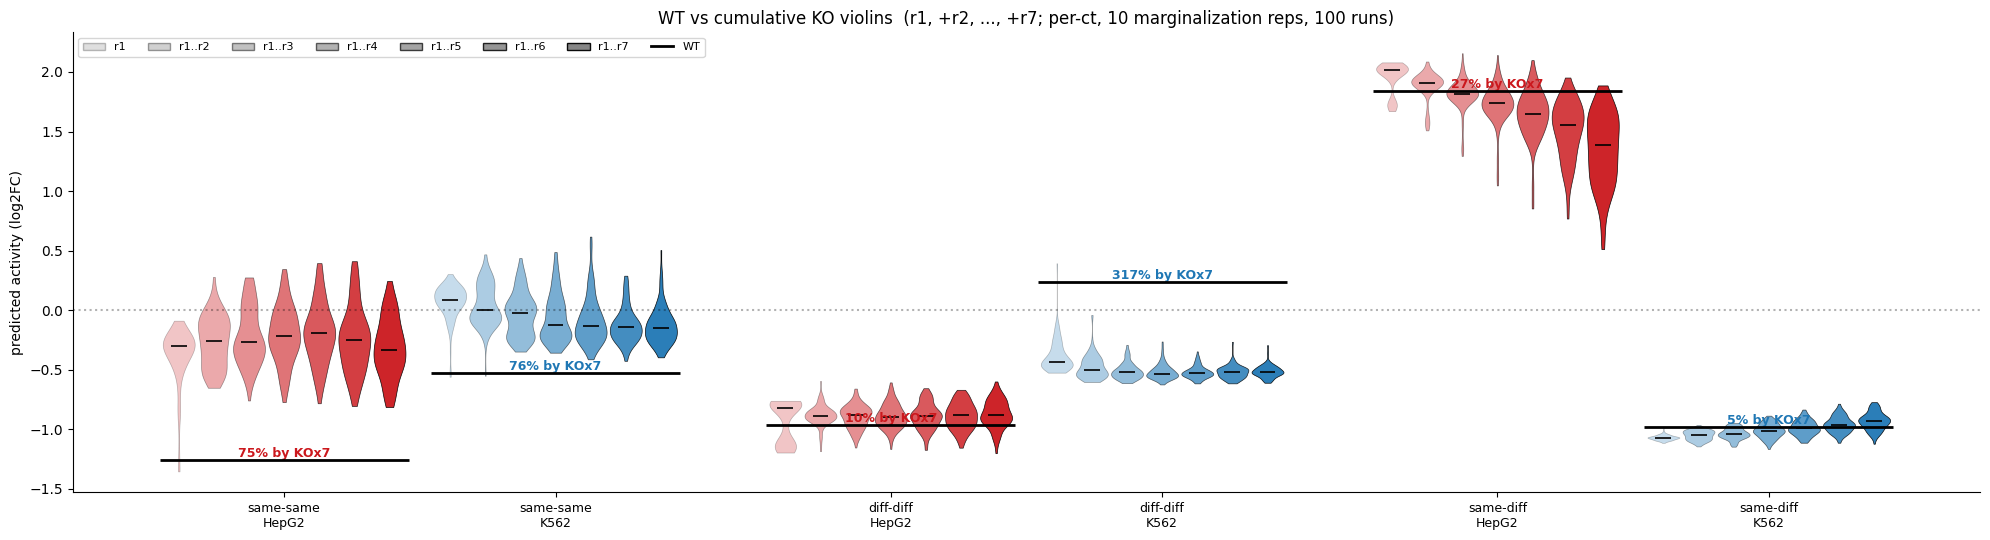

In [4]:
# Cumulative KO violin plot: per (seq, ct) -> WT line + N_ROUNDS violins (r1, +r2, ..., +rN)
N_REPS_KO = 10

wt_acts = {ct: {} for ct in CTS}
ko_cum = {ct: {name: [[] for _ in range(N_ROUNDS)] for name, _ in groups} for ct in CTS}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        wt_acts[ct][name] = float(em._predict_tensor(wt, models=models, batch_size=4)[ct][0])
        for run_i in range(N_RUNS):
            wins = [int(W[name][ct][run_i]) for W in all_winners]
            shuf = dinuc_shuf(wt, n=N_REPS_KO, random_state=int(idx)*9999 + run_i)[0]
            base = wt.expand(N_REPS_KO, -1, -1)
            for r in range(N_ROUNDS):
                chim = base.clone()
                for w in wins[:r+1]:
                    chim[:, :, w:w+WIN] = shuf[:, :, w:w+WIN]
                p = em._predict_tensor(chim, models=models, batch_size=128)[ct]
                ko_cum[ct][name][r].append(float(p.mean()))
        ko_cum[ct][name] = [np.array(a) for a in ko_cum[ct][name]]
        means = [a.mean() for a in ko_cum[ct][name]]
        print(f'{name} {ct}: WT={wt_acts[ct][name]:.2f}  ' +
              '  '.join(f'+r{r+1}={m:.2f}' for r, m in enumerate(means)))

# --- plot ---
order = ['same-same', 'diff-diff', 'same-diff']
ct_color = {'HepG2': '#cb181d', 'K562': '#1f77b4'}
tag_labels = ['r1'] + [f'r1..r{r+1}' for r in range(1, N_ROUNDS)]

VIOLIN_DX = 0.55
BUCKET_W = VIOLIN_DX * N_ROUNDS + 0.4
GAP = 1.0

fig, ax = plt.subplots(figsize=(20, 5.5))
xticks_main, xlabels_main = [], []

for i, name in enumerate(order):
    for j, ct in enumerate(CTS):
        center = i*(2*BUCKET_W + GAP) + j*BUCKET_W
        xticks_main.append(center + VIOLIN_DX*(N_ROUNDS-1)/2)
        xlabels_main.append(f'{name}\n{ct}')

        wt_v = wt_acts[ct][name]
        ko_full_mean = ko_cum[ct][name][-1].mean()
        pct = 100.0 * (wt_v - ko_full_mean) / wt_v if wt_v != 0 else float('nan')

        ax.hlines(wt_v, center - 0.3, center + VIOLIN_DX*(N_ROUNDS-1) + 0.3,
                  color='black', linewidth=2, zorder=6)

        for r in range(N_ROUNDS):
            x = center + r*VIOLIN_DX
            alpha = 0.25 + 0.7 * (r / max(N_ROUNDS - 1, 1))
            v = ax.violinplot([ko_cum[ct][name][r]], positions=[x],
                              widths=0.5, showmeans=False, showmedians=True,
                              showextrema=False)
            for body in v['bodies']:
                body.set_facecolor(ct_color[ct]); body.set_alpha(alpha)
                body.set_edgecolor('black'); body.set_linewidth(0.5)
            v['cmedians'].set_color('black'); v['cmedians'].set_linewidth(1.2)

        ax.text(center + VIOLIN_DX*(N_ROUNDS-1)/2, wt_v,
                f'{pct:.0f}% by KOx{N_ROUNDS}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=ct_color[ct])

ax.set_xticks(xticks_main); ax.set_xticklabels(xlabels_main, fontsize=9)
ax.axhline(0.0, color='k', ls=':', alpha=0.3)
ax.set_ylabel('predicted activity (log2FC)')
ax.set_title(f'WT vs cumulative KO violins  (r1, +r2, ..., +r{N_ROUNDS}; '
             f'per-ct, {N_REPS_KO} marginalization reps, {N_RUNS} runs)')

handles = [Patch(facecolor='gray',
                 alpha=0.25 + 0.7 * (r / max(N_ROUNDS - 1, 1)),
                 edgecolor='black', label=tag_labels[r]) for r in range(N_ROUNDS)]
handles.append(plt.Line2D([0], [0], color='black', linewidth=2, label='WT'))
ax.legend(handles=handles, loc='best', fontsize=8, ncol=N_ROUNDS+1)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

same-same HepG2: WT=-1.26  r1=-0.38  r2=-0.87  r3=-1.01  r4=-1.08  r5=-1.08  r6=-1.14  r7=-1.16  all=-0.31
same-same K562: WT=-0.53  r1=0.07  r2=-0.30  r3=-0.44  r4=-0.37  r5=-0.42  r6=-0.47  r7=-0.49  all=-0.13
diff-diff HepG2: WT=-0.96  r1=-0.94  r2=-0.94  r3=-0.97  r4=-0.96  r5=-0.98  r6=-0.97  r7=-0.94  all=-0.87
diff-diff K562: WT=0.24  r1=-0.38  r2=-0.08  r3=-0.01  r4=0.08  r5=0.06  r6=0.12  r7=0.12  all=-0.51
same-diff HepG2: WT=1.84  r1=1.96  r2=1.77  r3=1.80  r4=1.80  r5=1.82  r6=1.83  r7=1.83  all=1.34
same-diff K562: WT=-0.98  r1=-1.07  r2=-1.00  r3=-1.01  r4=-0.99  r5=-1.00  r6=-0.99  r7=-1.00  all=-0.93


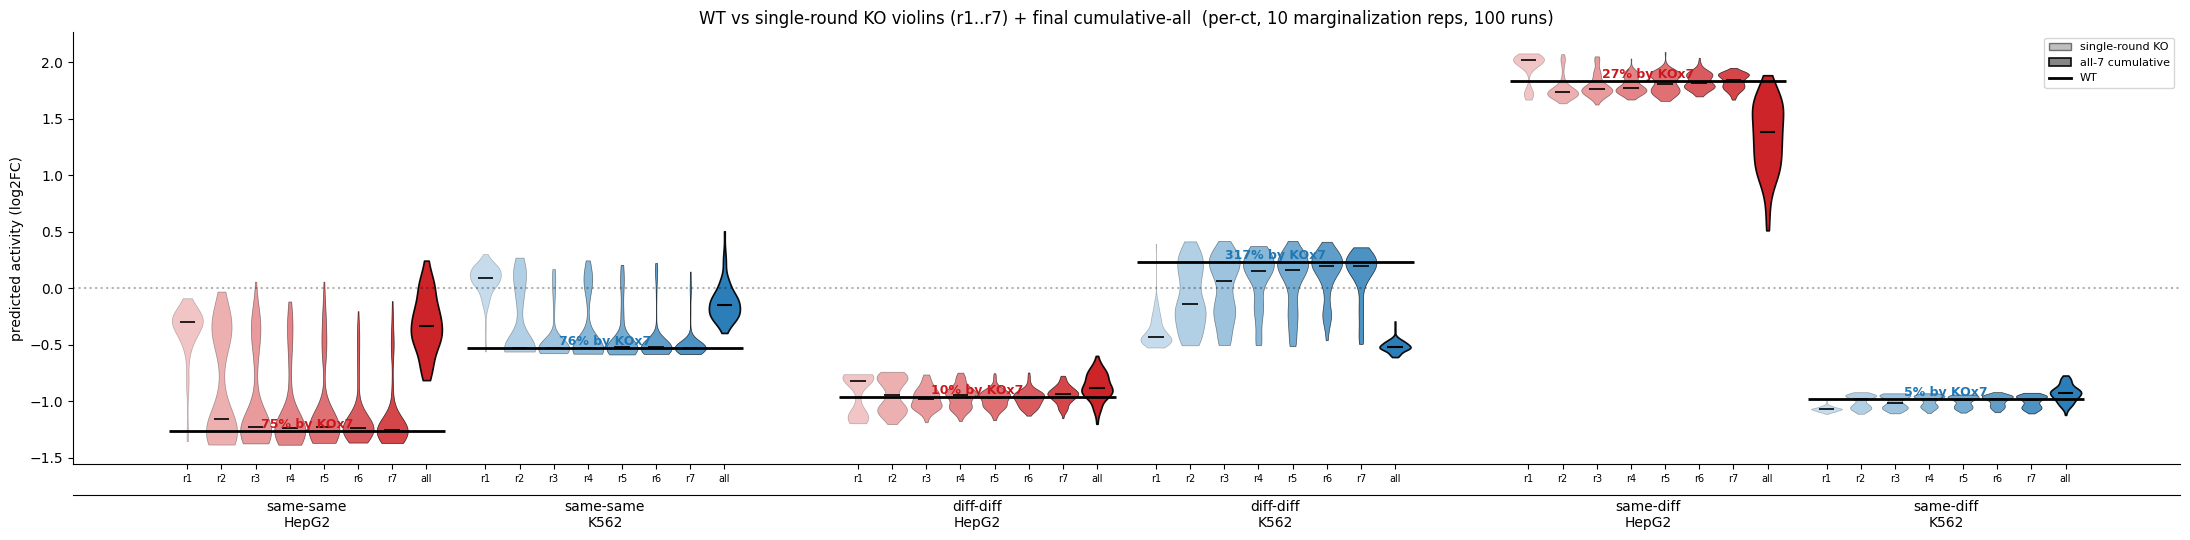

In [5]:
# Per-round single KO violins + final cumulative-all violin
# Per (seq, ct): WT line + 7 single-round violins (r1, r2, ..., r7) + 1 final "r1..r7" violin
ko_single = {ct: {name: [[] for _ in range(N_ROUNDS)] for name, _ in groups} for ct in CTS}
ko_all    = {ct: {name: [] for name, _ in groups} for ct in CTS}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        for run_i in range(N_RUNS):
            wins = [int(W[name][ct][run_i]) for W in all_winners]
            shuf = dinuc_shuf(wt, n=N_REPS_KO, random_state=int(idx)*9999 + run_i)[0]
            base = wt.expand(N_REPS_KO, -1, -1)
            # single-round KOs
            for r in range(N_ROUNDS):
                chim = base.clone()
                w = wins[r]
                chim[:, :, w:w+WIN] = shuf[:, :, w:w+WIN]
                p = em._predict_tensor(chim, models=models, batch_size=128)[ct]
                ko_single[ct][name][r].append(float(p.mean()))
            # all-rounds cumulative KO
            chim = base.clone()
            for w in wins:
                chim[:, :, w:w+WIN] = shuf[:, :, w:w+WIN]
            p = em._predict_tensor(chim, models=models, batch_size=128)[ct]
            ko_all[ct][name].append(float(p.mean()))
        ko_single[ct][name] = [np.array(a) for a in ko_single[ct][name]]
        ko_all[ct][name]    = np.array(ko_all[ct][name])
        print(f'{name} {ct}: WT={wt_acts[ct][name]:.2f}  ' +
              '  '.join(f'r{r+1}={ko_single[ct][name][r].mean():.2f}'
                        for r in range(N_ROUNDS)) +
              f"  all={ko_all[ct][name].mean():.2f}")

# --- plot ---
order = ['same-same', 'diff-diff', 'same-diff']
ct_color = {'HepG2': '#cb181d', 'K562': '#1f77b4'}
N_VIOL = N_ROUNDS + 1   # 7 single-round + 1 cumulative-all

VIOLIN_DX = 0.55
BUCKET_W = VIOLIN_DX * N_VIOL + 0.4
GAP = 1.2

fig, ax = plt.subplots(figsize=(22, 5.5))
xticks_main, xlabels_main = [], []

for i, name in enumerate(order):
    for j, ct in enumerate(CTS):
        center = i*(2*BUCKET_W + GAP) + j*BUCKET_W
        xticks_main.append(center + VIOLIN_DX*(N_VIOL-1)/2)
        xlabels_main.append(f'{name}\n{ct}')

        wt_v = wt_acts[ct][name]
        ko_full_mean = ko_all[ct][name].mean()
        pct = 100.0 * (wt_v - ko_full_mean) / wt_v if wt_v != 0 else float('nan')

        ax.hlines(wt_v, center - 0.3, center + VIOLIN_DX*(N_VIOL-1) + 0.3,
                  color='black', linewidth=2, zorder=6)

        # 7 single-round violins
        for r in range(N_ROUNDS):
            x = center + r*VIOLIN_DX
            alpha = 0.25 + 0.55 * (r / max(N_ROUNDS - 1, 1))
            v = ax.violinplot([ko_single[ct][name][r]], positions=[x],
                              widths=0.5, showmeans=False, showmedians=True,
                              showextrema=False)
            for body in v['bodies']:
                body.set_facecolor(ct_color[ct]); body.set_alpha(alpha)
                body.set_edgecolor('black'); body.set_linewidth(0.5)
            v['cmedians'].set_color('black'); v['cmedians'].set_linewidth(1.2)

        # final cumulative-all violin (offset slightly so it's visually separate)
        x_all = center + N_ROUNDS*VIOLIN_DX
        v = ax.violinplot([ko_all[ct][name]], positions=[x_all],
                          widths=0.5, showmeans=False, showmedians=True,
                          showextrema=False)
        for body in v['bodies']:
            body.set_facecolor(ct_color[ct]); body.set_alpha(0.95)
            body.set_edgecolor('black'); body.set_linewidth(1.2)
        v['cmedians'].set_color('black'); v['cmedians'].set_linewidth(1.5)

        ax.text(center + VIOLIN_DX*(N_VIOL-1)/2, wt_v,
                f'{pct:.0f}% by KOx{N_ROUNDS}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=ct_color[ct])

# x tick labels per violin (under each)
sub_xticks, sub_xlabels = [], []
for i, name in enumerate(order):
    for j, ct in enumerate(CTS):
        center = i*(2*BUCKET_W + GAP) + j*BUCKET_W
        for r in range(N_ROUNDS):
            sub_xticks.append(center + r*VIOLIN_DX)
            sub_xlabels.append(f'r{r+1}')
        sub_xticks.append(center + N_ROUNDS*VIOLIN_DX)
        sub_xlabels.append('all')

ax2 = ax.secondary_xaxis('bottom')
ax.set_xticks(sub_xticks); ax.set_xticklabels(sub_xlabels, fontsize=7)
ax2.set_xticks(xticks_main); ax2.set_xticklabels(xlabels_main, fontsize=9)
ax2.spines['bottom'].set_position(('outward', 22))
ax2.tick_params(length=0)

ax.axhline(0.0, color='k', ls=':', alpha=0.3)
ax.set_ylabel('predicted activity (log2FC)')
ax.set_title(f'WT vs single-round KO violins (r1..r{N_ROUNDS}) + final cumulative-all  '
             f'(per-ct, {N_REPS_KO} marginalization reps, {N_RUNS} runs)')

handles = [Patch(facecolor='gray', alpha=0.5, edgecolor='black', label='single-round KO'),
           Patch(facecolor='gray', alpha=0.95, edgecolor='black',
                 linewidth=1.2, label=f'all-{N_ROUNDS} cumulative'),
           plt.Line2D([0], [0], color='black', linewidth=2, label='WT')]
ax.legend(handles=handles, loc='best', fontsize=8)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()


In [2]:
# restore: load r1..r7 winners + recompute wt_acts (no screen rerun)                                                                                                                                                                                                                                                                                                                                                      
N_RUNS, N_TRY, N_REPS, WIN, N_REPS_KO = 100, 50, 10, 4, 10                                                                                                                                                                                                                                                                                                                                                                
N_ROUNDS = 7                                                                                                                                                                                                                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                                                                                                                                                                        
eigen_steering._load_heavy_deps()                                                                                                                                                                                                                                                                                                                                                                                         
dinuc_shuf = eigen_steering.dinucleotide_shuffle                                                                                                                                                                                                                                                                                                                                                                          
ENH_LEN = eigen_steering.ENHANCER_LEN                                                                                                                                                                                                                                                                                                                                                                                     
rng = np.random.default_rng(42)
                                                                                                                                                                                                                                                                                                                                                                                                                        
with open(os.path.join(REPO, 'genomic_targets', 'data',                                                                                                                                                                                                                                                                                                                                                                   
                        'kcee_forward_screen_r1to7.pkl'), 'rb') as f:                                                                                                                                                                                                                                                                                                                                                      
    saved = pickle.load(f)                                                                                                                                                                                                                                                                                                                                                                                                
all_winners = saved['all_winners']
print('loaded all_winners, len=', len(all_winners))                                                                                                                                                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                                                                                                                                                                                        
wt_acts = {ct: {} for ct in CTS}                                                                                                                                                                                                                                                                                                                                                                                          
for name, idx in groups:                                                                                                                                                                                                                                                                                                                                                                                                  
    wt = em.X[idx:idx+1].float()                                                                                                                                                                                                                                                                                                                                                                                          
    for ct in CTS:                                                                                                                                                                                                                                                                                                                                                                                                        
        wt_acts[ct][name] = float(em._predict_tensor(wt, models=models, batch_size=4)[ct][0])
print('wt_acts ready')                                                                      

loaded all_winners, len= 7
wt_acts ready


r8 same-same: done
r8 diff-diff: done
r8 same-diff: done
r9 same-same: done
r9 diff-diff: done
r9 same-diff: done
r10 same-same: done
r10 diff-diff: done
r10 same-diff: done
r11 same-same: done
r11 diff-diff: done
r11 same-diff: done
r12 same-same: done
r12 diff-diff: done
r12 same-diff: done
saved -> /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/kcee_forward_screen_r1to12.pkl


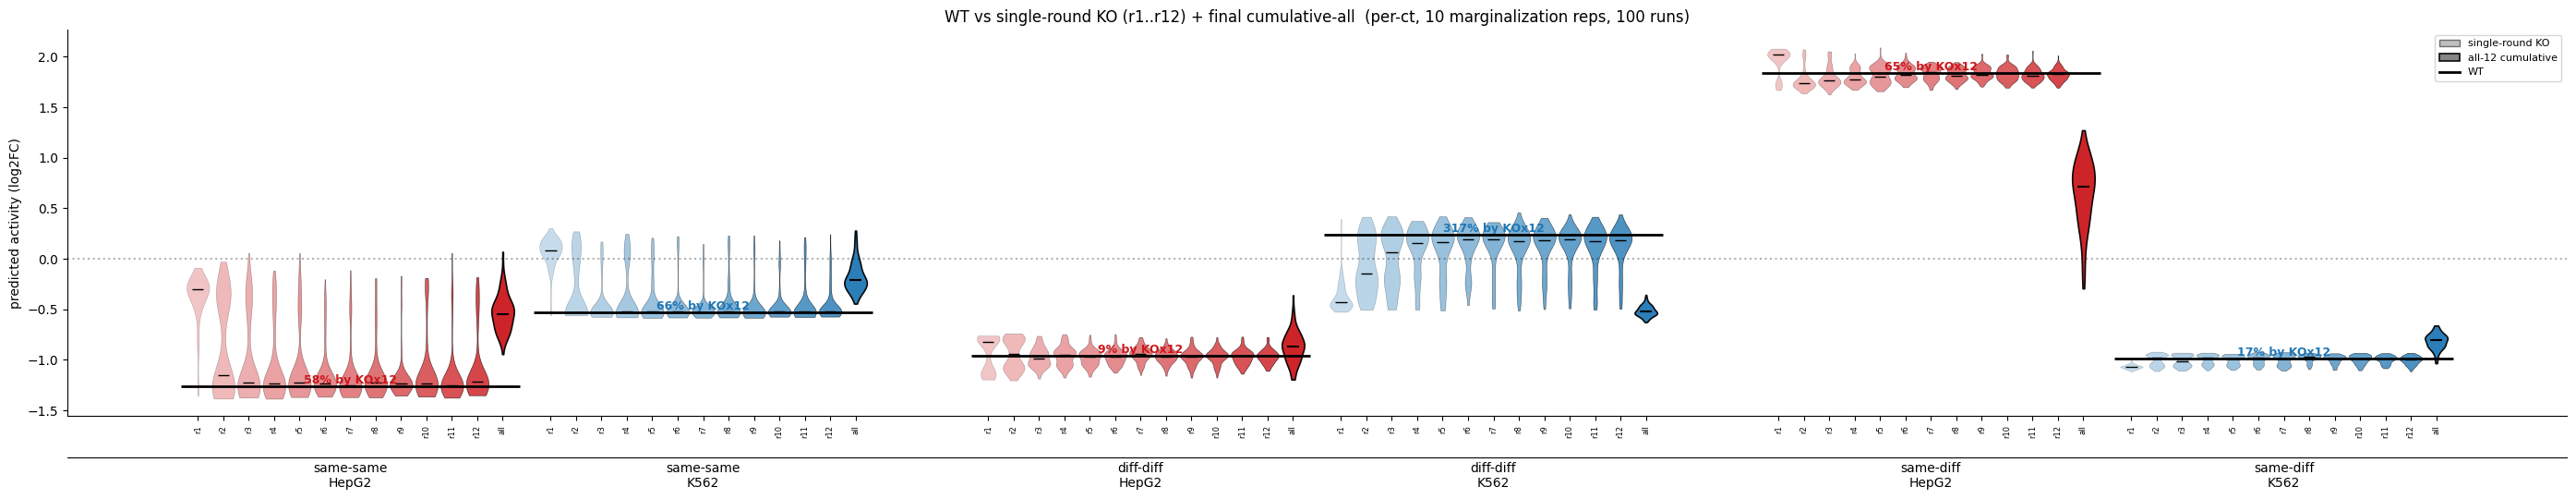

In [3]:
# continue forward screen for 5 more rounds (r8..r12), then redo same plot for all rounds
EXTRA_ROUNDS = 5
start_r = len(all_winners)              # 7 already done

for r in range(start_r, start_r + EXTRA_ROUNDS):
    wnext = {name: {ct: [] for ct in CTS} for name, _ in groups}
    for name, idx in groups:
        wt = em.X[idx:idx+1].float()
        for ct in CTS:
            for run_i in range(N_RUNS):
                prior = [int(W[name][ct][run_i]) for W in all_winners]
                wt_ko = wt.clone()
                ko_shuf = dinuc_shuf(wt, n=1,
                                     random_state=int(idx)*333 + run_i*23 + (r+1)*sum(prior))[0]
                for w in prior:
                    wt_ko[:, :, w:w+WIN] = ko_shuf[:, :, w:w+WIN]
                wt_p = float(em._predict_tensor(wt_ko, models=models, batch_size=4)[ct][0])

                starts = rng.integers(0, ENH_LEN - WIN + 1, size=N_TRY)
                chunks = []
                for s in starts:
                    shuf = dinuc_shuf(wt_ko, n=N_REPS,
                                      random_state=int(idx)*1_000_000 + run_i*1000 + int(s) + r)[0]
                    chim = wt_ko.expand(N_REPS, -1, -1).clone()
                    chim[:, :, s:s+WIN] = shuf[:, :, s:s+WIN]
                    chunks.append(chim)
                all_chim = torch.cat(chunks, dim=0)
                p = em._predict_tensor(all_chim, models=models, batch_size=128)[ct]
                pm = p.reshape(N_TRY, N_REPS).mean(axis=1)
                impact = np.abs(pm - wt_p)
                wnext[name][ct].append(int(starts[int(impact.argmax())]))
            wnext[name][ct] = np.array(wnext[name][ct])
        print(f'r{r+1} {name}: done')
    all_winners.append(wnext)

N_ROUNDS = len(all_winners)   # now 12

# save extended winners
OUT = os.path.join(REPO, 'genomic_targets', 'data', f'kcee_forward_screen_r1to{N_ROUNDS}.pkl')
with open(OUT, 'wb') as f:
    pickle.dump({'all_winners': all_winners, 'reps': reps,
                 'WIN': WIN, 'N_RUNS': N_RUNS, 'N_TRY': N_TRY, 'N_REPS': N_REPS}, f)
print('saved ->', OUT)

# --- recompute single-round + cumulative-all KO activities for all rounds ---
ko_single = {ct: {name: [[] for _ in range(N_ROUNDS)] for name, _ in groups} for ct in CTS}
ko_all    = {ct: {name: [] for name, _ in groups} for ct in CTS}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        for run_i in range(N_RUNS):
            wins = [int(W[name][ct][run_i]) for W in all_winners]
            shuf = dinuc_shuf(wt, n=N_REPS_KO, random_state=int(idx)*9999 + run_i)[0]
            base = wt.expand(N_REPS_KO, -1, -1)
            for r in range(N_ROUNDS):
                chim = base.clone()
                w = wins[r]
                chim[:, :, w:w+WIN] = shuf[:, :, w:w+WIN]
                p = em._predict_tensor(chim, models=models, batch_size=128)[ct]
                ko_single[ct][name][r].append(float(p.mean()))
            chim = base.clone()
            for w in wins:
                chim[:, :, w:w+WIN] = shuf[:, :, w:w+WIN]
            p = em._predict_tensor(chim, models=models, batch_size=128)[ct]
            ko_all[ct][name].append(float(p.mean()))
        ko_single[ct][name] = [np.array(a) for a in ko_single[ct][name]]
        ko_all[ct][name]    = np.array(ko_all[ct][name])

# --- plot ---
order = ['same-same', 'diff-diff', 'same-diff']
ct_color = {'HepG2': '#cb181d', 'K562': '#1f77b4'}
N_VIOL = N_ROUNDS + 1

VIOLIN_DX = 0.45
BUCKET_W = VIOLIN_DX * N_VIOL + 0.4
GAP = 1.5

fig, ax = plt.subplots(figsize=(28, 5.5))
xticks_main, xlabels_main = [], []
sub_xticks, sub_xlabels = [], []

for i, name in enumerate(order):
    for j, ct in enumerate(CTS):
        center = i*(2*BUCKET_W + GAP) + j*BUCKET_W
        xticks_main.append(center + VIOLIN_DX*(N_VIOL-1)/2)
        xlabels_main.append(f'{name}\n{ct}')

        wt_v = wt_acts[ct][name]
        pct = 100.0 * (wt_v - ko_all[ct][name].mean()) / wt_v if wt_v != 0 else float('nan')

        ax.hlines(wt_v, center - 0.3, center + VIOLIN_DX*(N_VIOL-1) + 0.3,
                  color='black', linewidth=2, zorder=6)

        for r in range(N_ROUNDS):
            x = center + r*VIOLIN_DX
            alpha = 0.25 + 0.55 * (r / max(N_ROUNDS - 1, 1))
            v = ax.violinplot([ko_single[ct][name][r]], positions=[x],
                              widths=0.4, showmeans=False, showmedians=True,
                              showextrema=False)
            for body in v['bodies']:
                body.set_facecolor(ct_color[ct]); body.set_alpha(alpha)
                body.set_edgecolor('black'); body.set_linewidth(0.4)
            v['cmedians'].set_color('black'); v['cmedians'].set_linewidth(1.0)
            sub_xticks.append(x); sub_xlabels.append(f'r{r+1}')

        x_all = center + N_ROUNDS*VIOLIN_DX
        v = ax.violinplot([ko_all[ct][name]], positions=[x_all],
                          widths=0.4, showmeans=False, showmedians=True,
                          showextrema=False)
        for body in v['bodies']:
            body.set_facecolor(ct_color[ct]); body.set_alpha(0.95)
            body.set_edgecolor('black'); body.set_linewidth(1.2)
        v['cmedians'].set_color('black'); v['cmedians'].set_linewidth(1.5)
        sub_xticks.append(x_all); sub_xlabels.append('all')

        ax.text(center + VIOLIN_DX*(N_VIOL-1)/2, wt_v,
                f'{pct:.0f}% by KOx{N_ROUNDS}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=ct_color[ct])

ax2 = ax.secondary_xaxis('bottom')
ax.set_xticks(sub_xticks); ax.set_xticklabels(sub_xlabels, fontsize=6, rotation=90)
ax2.set_xticks(xticks_main); ax2.set_xticklabels(xlabels_main, fontsize=9)
ax2.spines['bottom'].set_position(('outward', 32))
ax2.tick_params(length=0)

ax.axhline(0.0, color='k', ls=':', alpha=0.3)
ax.set_ylabel('predicted activity (log2FC)')
ax.set_title(f'WT vs single-round KO (r1..r{N_ROUNDS}) + final cumulative-all  '
             f'(per-ct, {N_REPS_KO} marginalization reps, {N_RUNS} runs)')

handles = [Patch(facecolor='gray', alpha=0.5, edgecolor='black', label='single-round KO'),
           Patch(facecolor='gray', alpha=0.95, edgecolor='black',
                 linewidth=1.2, label=f'all-{N_ROUNDS} cumulative'),
           plt.Line2D([0], [0], color='black', linewidth=2, label='WT')]
ax.legend(handles=handles, loc='best', fontsize=8)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()


same-same HepG2: WT=-1.26  +r1=-0.38  +r2=-0.26  +r3=-0.21  +r4=-0.20  +r5=-0.19  +r6=-0.24  +r7=-0.31  +r8=-0.36  +r9=-0.41  +r10=-0.46  +r11=-0.51  +r12=-0.53
same-same K562: WT=-0.53  +r1=0.07  +r2=0.05  +r3=-0.04  +r4=-0.06  +r5=-0.08  +r6=-0.12  +r7=-0.13  +r8=-0.13  +r9=-0.17  +r10=-0.17  +r11=-0.17  +r12=-0.18
diff-diff HepG2: WT=-0.96  +r1=-0.94  +r2=-0.88  +r3=-0.89  +r4=-0.89  +r5=-0.89  +r6=-0.89  +r7=-0.87  +r8=-0.86  +r9=-0.86  +r10=-0.86  +r11=-0.87  +r12=-0.87
diff-diff K562: WT=0.24  +r1=-0.38  +r2=-0.47  +r3=-0.51  +r4=-0.51  +r5=-0.52  +r6=-0.52  +r7=-0.51  +r8=-0.51  +r9=-0.51  +r10=-0.52  +r11=-0.52  +r12=-0.52
same-diff HepG2: WT=1.84  +r1=1.96  +r2=1.88  +r3=1.81  +r4=1.73  +r5=1.64  +r6=1.51  +r7=1.34  +r8=1.19  +r9=1.03  +r10=0.90  +r11=0.77  +r12=0.65
same-diff K562: WT=-0.98  +r1=-1.07  +r2=-1.05  +r3=-1.03  +r4=-1.01  +r5=-0.99  +r6=-0.96  +r7=-0.93  +r8=-0.89  +r9=-0.87  +r10=-0.85  +r11=-0.83  +r12=-0.82


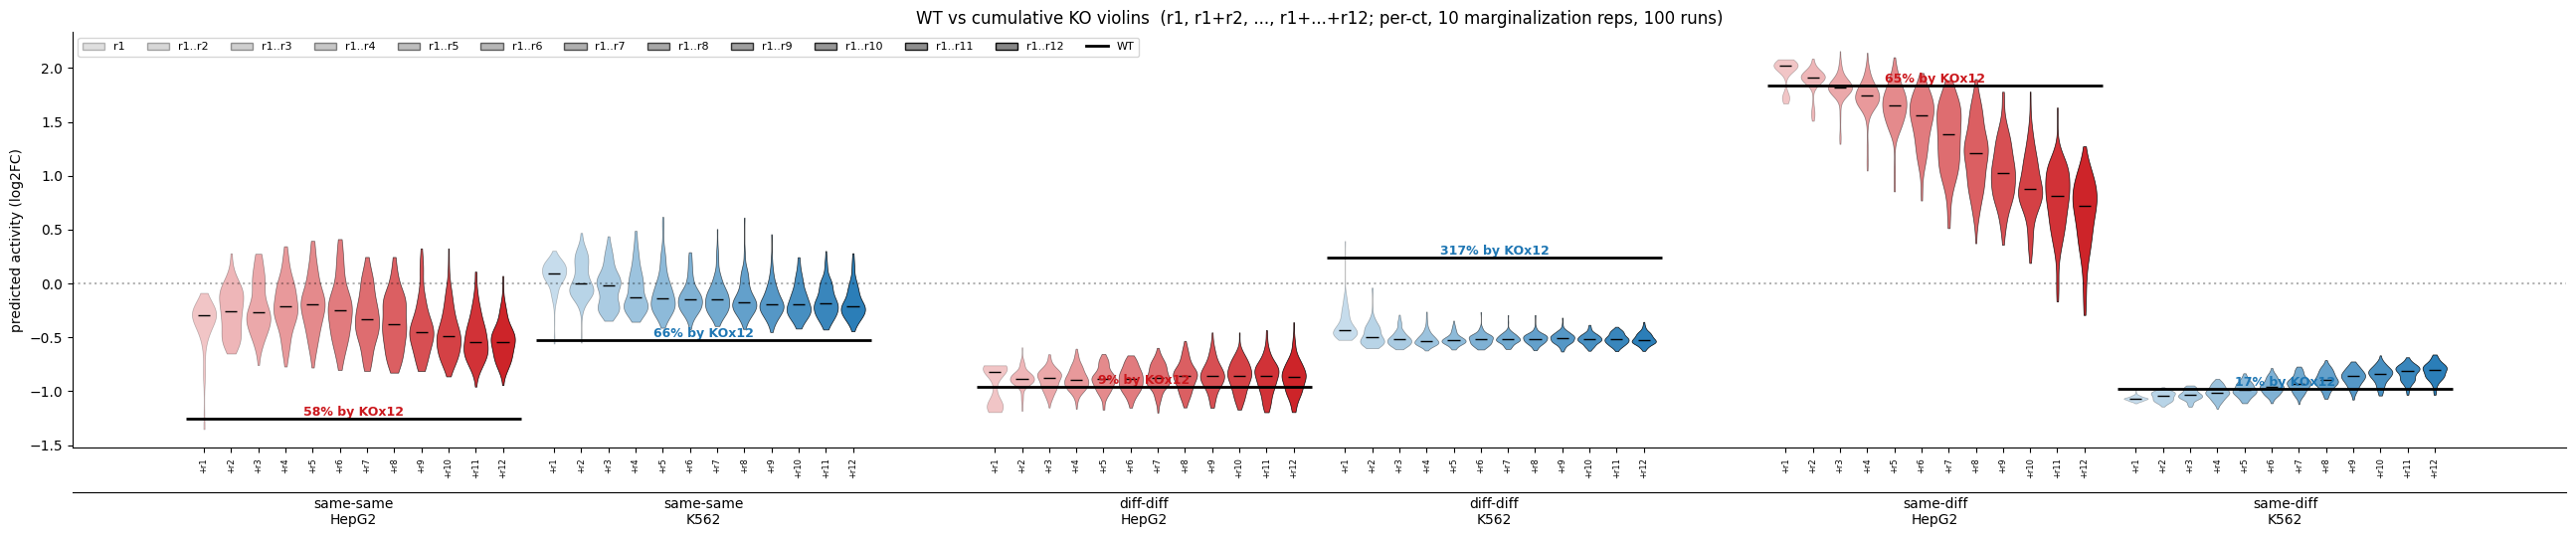

In [4]:
# Cumulative-progression KO violin plot for ALL N_ROUNDS rounds (r1, r1+r2, ..., r1+...+rN)
ko_cum = {ct: {name: [[] for _ in range(N_ROUNDS)] for name, _ in groups} for ct in CTS}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        for run_i in range(N_RUNS):
            wins = [int(W[name][ct][run_i]) for W in all_winners]
            shuf = dinuc_shuf(wt, n=N_REPS_KO, random_state=int(idx)*9999 + run_i)[0]
            base = wt.expand(N_REPS_KO, -1, -1)
            for r in range(N_ROUNDS):
                chim = base.clone()
                for w in wins[:r+1]:
                    chim[:, :, w:w+WIN] = shuf[:, :, w:w+WIN]
                p = em._predict_tensor(chim, models=models, batch_size=128)[ct]
                ko_cum[ct][name][r].append(float(p.mean()))
        ko_cum[ct][name] = [np.array(a) for a in ko_cum[ct][name]]
        means = [a.mean() for a in ko_cum[ct][name]]
        print(f'{name} {ct}: WT={wt_acts[ct][name]:.2f}  ' +
              '  '.join(f'+r{r+1}={m:.2f}' for r, m in enumerate(means)))

# --- plot ---
order = ['same-same', 'diff-diff', 'same-diff']
ct_color = {'HepG2': '#cb181d', 'K562': '#1f77b4'}
tag_labels = ['r1'] + [f'r1..r{r+1}' for r in range(1, N_ROUNDS)]

VIOLIN_DX = 0.45
BUCKET_W = VIOLIN_DX * N_ROUNDS + 0.4
GAP = 1.5

fig, ax = plt.subplots(figsize=(26, 5.5))
xticks_main, xlabels_main = [], []
sub_xticks, sub_xlabels = [], []

for i, name in enumerate(order):
    for j, ct in enumerate(CTS):
        center = i*(2*BUCKET_W + GAP) + j*BUCKET_W
        xticks_main.append(center + VIOLIN_DX*(N_ROUNDS-1)/2)
        xlabels_main.append(f'{name}\n{ct}')

        wt_v = wt_acts[ct][name]
        ko_full_mean = ko_cum[ct][name][-1].mean()
        pct = 100.0 * (wt_v - ko_full_mean) / wt_v if wt_v != 0 else float('nan')

        ax.hlines(wt_v, center - 0.3, center + VIOLIN_DX*(N_ROUNDS-1) + 0.3,
                  color='black', linewidth=2, zorder=6)

        for r in range(N_ROUNDS):
            x = center + r*VIOLIN_DX
            alpha = 0.25 + 0.7 * (r / max(N_ROUNDS - 1, 1))
            v = ax.violinplot([ko_cum[ct][name][r]], positions=[x],
                              widths=0.4, showmeans=False, showmedians=True,
                              showextrema=False)
            for body in v['bodies']:
                body.set_facecolor(ct_color[ct]); body.set_alpha(alpha)
                body.set_edgecolor('black'); body.set_linewidth(0.5)
            v['cmedians'].set_color('black'); v['cmedians'].set_linewidth(1.0)
            sub_xticks.append(x); sub_xlabels.append(f'+r{r+1}')

        ax.text(center + VIOLIN_DX*(N_ROUNDS-1)/2, wt_v,
                f'{pct:.0f}% by KOx{N_ROUNDS}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=ct_color[ct])

ax2 = ax.secondary_xaxis('bottom')
ax.set_xticks(sub_xticks); ax.set_xticklabels(sub_xlabels, fontsize=6, rotation=90)
ax2.set_xticks(xticks_main); ax2.set_xticklabels(xlabels_main, fontsize=9)
ax2.spines['bottom'].set_position(('outward', 32))
ax2.tick_params(length=0)

ax.axhline(0.0, color='k', ls=':', alpha=0.3)
ax.set_ylabel('predicted activity (log2FC)')
ax.set_title(f'WT vs cumulative KO violins  (r1, r1+r2, ..., r1+...+r{N_ROUNDS}; '
             f'per-ct, {N_REPS_KO} marginalization reps, {N_RUNS} runs)')

handles = [Patch(facecolor='gray',
                 alpha=0.25 + 0.7 * (r / max(N_ROUNDS - 1, 1)),
                 edgecolor='black', label=tag_labels[r]) for r in range(N_ROUNDS)]
handles.append(plt.Line2D([0], [0], color='black', linewidth=2, label='WT'))
ax.legend(handles=handles, loc='best', fontsize=8, ncol=N_ROUNDS+1)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()


EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
  K562: 17 motif hits (p<0.05)
  HepG2: 17 motif hits (p<0.05)
same-same HepG2: max-nec r5 pos=174, nec=0.108
same-same K562: max-nec r5 pos=122, nec=0.059
diff-diff HepG2: max-nec r5 pos=107, nec=0.204
diff-diff K562: max-nec r5 pos=61, nec=0.748
same-diff HepG2: max-nec r5 pos=182, nec=0.177
same-diff K562: max-nec r5 pos=152, nec=0.118
same-same HepG2 k-cee r5: cov=4bp  delta=+0.103  per_bp=+0.0259
same-same HepG2 modisco: cov=26bp  delta=-1.256  per_bp=-0.0483
same-same K562 k-cee r5: cov=4bp  delta=+0.054  per_bp=+0.0136
same-same K562 modisco: cov=38bp  delta=-0.544  per_bp=-0.0143
diff-diff HepG2 k-cee r5: cov=4bp  delta=+0.196  per_bp=+0.0490
diff-diff K562 k-cee r5: cov=4bp  delta=+0.609  per_bp=+0.1521
diff-diff K562 modisco: cov=57bp  delta=+0.844  per_bp=+0.0148
same-diff HepG2 k-cee r5: cov=4bp  delta=+0.120  per_bp=+0.0300
same-diff HepG2 modisco: cov=123bp  delta=+2.863  per_bp=+0.023

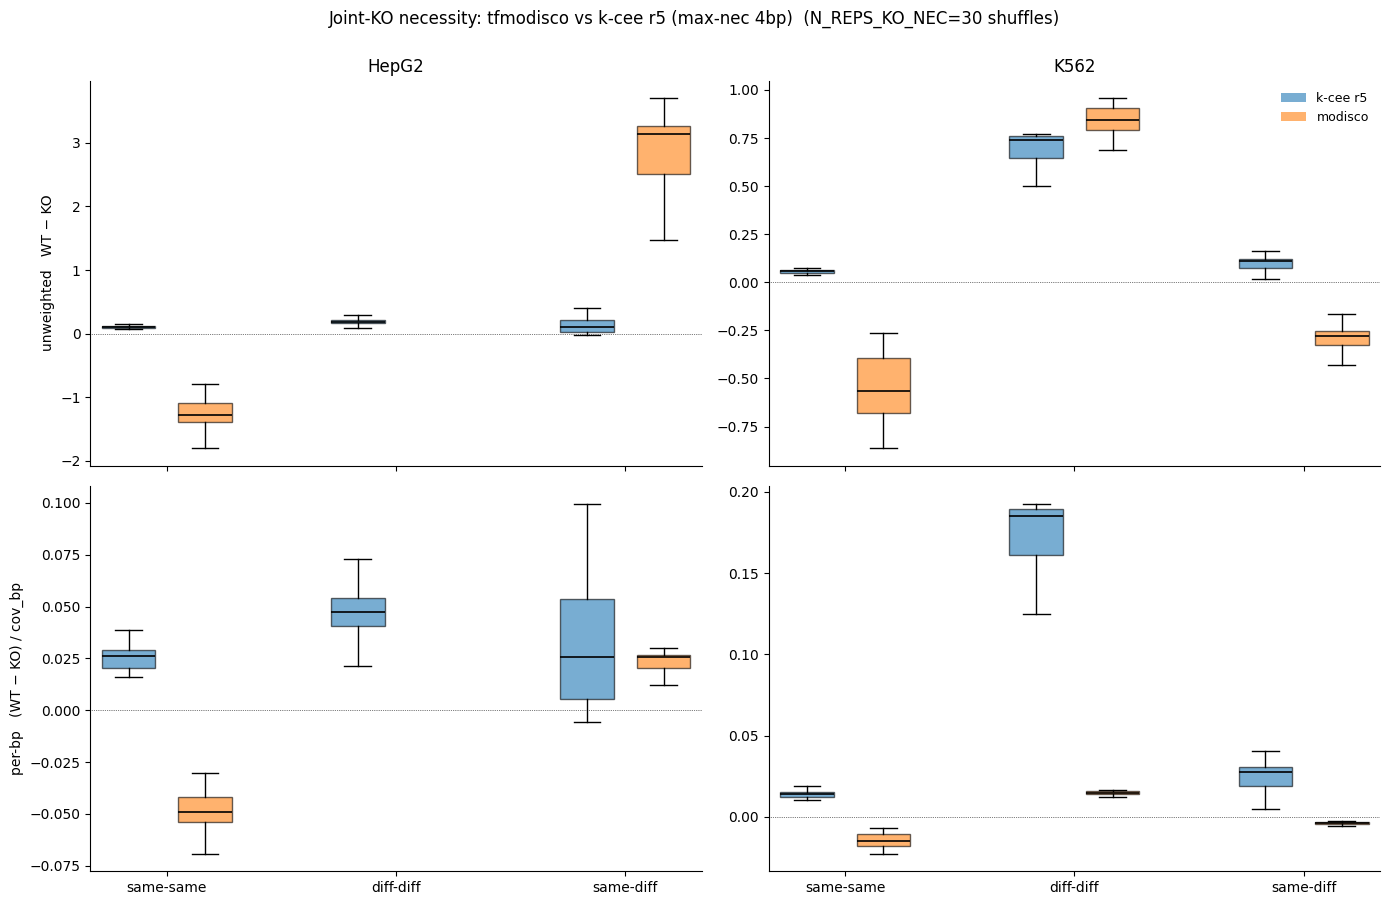

In [ ]:
# Joint-KO necessity: tfmodisco motif annotations vs k-cee r5 max-necessity annotation
# k-cee r5 annotation = pick the run (out of 100) whose r5 4bp winner has the
# highest single-KO necessity, use that 4bp window as the annotation.

R5_IDX = 4   # all_winners index for round 5

# 1) annotate motifs on the 3-seq subset (per-ct positions, never union)
em_sub = EigenMap(model_names=CT, device=DEVICE)
em_sub.X = em.X[sub_idx]
em_sub.constructs = [em.constructs[i] for i in sub_idx]
for ct in CT:
    em_sub.attr[ct]       = em.attr[ct][sub_idx]
    em_sub.attr_hyp[ct]   = em.attr_hyp[ct][sub_idx]    
    em_sub.importance[ct] = em.importance[ct][sub_idx]
em_sub.annotate_motifs(window_size=10, flank=1, pval_thresh=0.05, n_nearest=3)

# 2) k-cee r5 max-necessity 4bp window per (seq, ct)
kcee_r5_pos = {ct: {} for ct in CTS}
for name, idx in groups:
    for ct in CTS:
        nec = wt_acts[ct][name] - ko_single[ct][name][R5_IDX]
        argmax_run = int(nec.argmax())
        kcee_r5_pos[ct][name] = int(all_winners[R5_IDX][name][ct][argmax_run])
        print(f'{name} {ct}: max-nec r5 pos={kcee_r5_pos[ct][name]}, nec={nec[argmax_run]:.3f}')

# 3) joint-KO necessity for each method
def merge_intervals(intervals):
    if not intervals: return []
    iv = sorted(intervals)
    out = [list(iv[0])]
    for s, e in iv[1:]:
        if s <= out[-1][1]: out[-1][1] = max(out[-1][1], e)
        else: out.append([s, e])
    return [tuple(x) for x in out]

N_REPS_KO_NEC = 30
records = []
for r_sub, (name, seq_i) in enumerate(groups):
    wt = em.X[seq_i:seq_i+1].float()
    wt_pred = em._predict_tensor(wt, models=models, batch_size=4)
    wt_p = {ct: float(wt_pred[ct][0]) for ct in CTS}

    for ct in CTS:
        kcee_regions = merge_intervals([(kcee_r5_pos[ct][name],
                                         kcee_r5_pos[ct][name] + WIN)])
        modisco_regions = merge_intervals([
            (h['start'], min(h['end'], ENH_LEN))
            for h in em_sub.motif_hits[ct][r_sub] if h['start'] < ENH_LEN
        ])
        for method, regions in [('k-cee r5', kcee_regions),
                                ('modisco',  modisco_regions)]:
            cov_bp = sum(e - s for s, e in regions)
            if cov_bp == 0:
                continue
            shuf = dinuc_shuf(wt, n=N_REPS_KO_NEC,
                              random_state=int(seq_i)*97 + hash(method) % 1000)[0]
            chim = wt.expand(N_REPS_KO_NEC, -1, -1).clone()
            for s, e in regions:
                chim[:, :, s:e] = shuf[:, :, s:e]
            p = em._predict_tensor(chim, models=models, batch_size=128)
            deltas = wt_p[ct] - p[ct]
            for d_v in deltas:
                records.append({
                    'group': name, 'ct': ct, 'method': method,
                    'cov_bp': cov_bp,
                    'delta': float(d_v),
                    'per_bp': float(d_v) / cov_bp,
                })
            print(f'{name} {ct} {method}: cov={cov_bp}bp  '
                  f'delta={deltas.mean():+.3f}  per_bp={(deltas/cov_bp).mean():+.4f}')

df_rec = pd.DataFrame(records)

# 4) 2x2 box plots: unweighted (top) + per-bp (bottom); per-ct columns
method_color = {'k-cee r5': '#1f77b4', 'modisco': '#ff7f0e'}
xs_order = ['same-same', 'diff-diff', 'same-diff']
methods = ['k-cee r5', 'modisco']

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex='col')
for row, (ycol, ylab) in enumerate([('delta',  'unweighted   WT − KO'),
                                    ('per_bp', 'per-bp   (WT − KO) / cov_bp')]):
    for ci, ct in enumerate(CTS):
        ax = axes[row, ci]
        sub = df_rec[df_rec['ct'] == ct]
        positions, box_data, box_colors, xticks_pos = [], [], [], []
        for gi, g in enumerate(xs_order):
            for mi, m in enumerate(methods):
                vals = sub[(sub['group'] == g) & (sub['method'] == m)][ycol].values
                if len(vals) == 0: continue
                pos = gi*(len(methods)+1) + mi
                positions.append(pos); box_data.append(vals); box_colors.append(method_color[m])
            xticks_pos.append(gi*(len(methods)+1) + (len(methods)-1)/2)
        bp = ax.boxplot(box_data, positions=positions, widths=0.7,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color='black', linewidth=1.2))
        for patch, c in zip(bp['boxes'], box_colors):
            patch.set_facecolor(c); patch.set_alpha(0.6)
        ax.axhline(0, color='k', lw=0.5, ls=':')
        ax.set_xticks(xticks_pos); ax.set_xticklabels(xs_order)
        if row == 0: ax.set_title(ct)
        if ci == 0: ax.set_ylabel(ylab)
        for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

axes[0, -1].legend(handles=[Patch(facecolor=method_color[m], alpha=0.6, label=m)
                            for m in methods],
                   loc='upper right', fontsize=9, frameon=False)
plt.suptitle(f'Joint-KO necessity: tfmodisco vs k-cee r5 (max-nec 4bp)  '
             f'(N_REPS_KO_NEC={N_REPS_KO_NEC} shuffles)', y=1.00)
plt.tight_layout(); plt.show()
